<font size="+4">`Signal and Audio Processing`</font>

<font size="+3">`Seminar 08: Automatic Speech Recognition`</font>

<font size="+2">`Maks Nakhodnov & Dmitry Kropotov`</font>

<font size="+2">`Bremen, 2026`</font>

Что вы узнаете из этого ноутбука:

* Авторегрессионные модели. Transducer (RNN-T) и 2D-выравнивание. Encoder-Decoder модели (LAS, Whisper) и проблема Exposure Bias.
* Streaming ASR. Каузальная адаптация энкодеров, Chunk-wise Attention и компромисс между задержкой (Lookahead) и качеством.
* Sequence-Level Training (MWER) через Reinforcement Learning.
* Decoder-only SpeechLLM (Qwen, Seed-ASR).

In [1]:
import io
import os

os.environ['TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL'] = '1'

from urllib.request import urlopen

import regex

import numpy as np

import torch
import torchaudio
import torchmetrics

import soundfile

import matplotlib
import matplotlib.pyplot as plt

from IPython.display import Audio

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

<b style='color:red;'>В чем заключается главный недостаток CTC?</b>

<details><summary>Ответ:</summary>>> 

В свойстве <b>Contextual Independence (Условная независимость)</b>. 
Модель делает предсказание $p_t(a_t | X)$ на фрейме $t$, опираясь только на акустику $X$. Она ничего не знает о том, что сама же предсказала на шаге $t-1$. Из-за отсутствия доступа к собственной истории, CTC может выдать непроизносимую или грамматически неверную последовательность букв.
</details>

Несмотря на высокое итоговое качество Encoder-only моделей **(1)** свойство *условной независимости выходов приводит к необходимости использовать сложные процедуры декодинга* для получения удовлетворительного качества. Другим ограничением является **(2)** *жёсткая связь длины выхода и препроцессинга входа*: модель предсказывает столько токенов, сколько есть фреймов (с учётом понижения временного разрешения через CNN слои). С одной стороны это может приводить к предсказанию лишних Blank символов, если вход достаточно длинный, а с другой стороны, токенов выхода может не хватить, чтобы закодировать все необходимые выходные символы.   

Классическим способом введения зависимости входов между собой является авторегрессионный подход. В задаче ASR есть три представителя использующих авторегрессионную парадигму:
1. Transducer
2. Encoder-decoder
3. Decoder-only

<b style='color:red;'>Вообще говоря, добавлять зависимость между токенами можно очень по-разному. Например, Non-Autoregressive модели часто реализуют это на основе Encoder-only моделей. Предложите, как можно модифицировать Conformer, чтобы получить NAR?</b>
<details><summary>Ответ:</summary>>> 

1. Простейший вариант — навесить поверх энкодера Masked LLM для исправления ошибок в черновом выходе CTC модели. Представители: Mask-CTC, CMLM.
2. Можно объединить Masked LM и энкодер путём подмешивания CTC предсказаний на промежуточных слоях в скрытые представления на следующем слое. Хотя формально, это не меняет структуры модели и свойство условной независимости в строгом смысле не меняется, оно ослабляется за счёт явного добавления информации о частичном результате. Представители: Self-Conditioned CTC.
3. Можно заменить CTC лосс, который является следствием 0-order Markov assumption, на Conditional random field.
4. ...

</details>

# `1. Transducer`

## `1.1. Архитектура`

![](https://lorenlugosch.github.io/images/transducer/transducer-model.png)

Базовая архитектура была предложена для машинного перевода в статье [Sequence Transduction with Recurrent Neural Networks](https://arxiv.org/pdf/1211.3711). Затем, Google адаптировала подход для задачи ASR: [Streaming End-to-end Speech Recognition For Mobile Devices](https://arxiv.org/pdf/1811.06621).

Рассмотрим три компонента архитектуры:

1. **Encoder (Acoustic Network):**

   Сжимает входную спектрограмму $X$ в последовательность акустических представлений длины $T$:
$$
\mathbf{h}^{\text{enc}}_t = \text{Encoder}(X)_t
$$

**В качестве Encoder может выступать любая архитектура. В оригинальной статье, эту роль выполняла LSTM, однако, Conformer-like архитектура является стандартным выбором сейчас.**

2. **Prediction Network (Language Model):** 

   Принимает на вход *уже сгенерированные* непустые токены $y_{<u}$ и выдает скрытое состояние языка для шага $u$:
$$
\mathbf{h}^{\text{pred}}_u = \text{Predictor}(y_{<u}) = \text{Predictor}(\{y_0, y_1, \dots, y_{u-1}\}),
$$
   где $y_0$ — это специальный токен `<sos>` или пустой вектор).

**В качестве Prediction Network также может быть любая *авторегрессионная* архитектура. В оригинальной статье, эту роль выполняла LSTM. В качестве более сильной альтернативы можно использовать LSTM с attention, а также обычный Transformer. В качестве более быстрой альтернативы могут выступать State Space Models, которые избегают квадратичной сложности инференса.**

3. **Joint Network:**

   Берет акустический вектор для фрейма $t$ и языковой вектор для префикса $u$, объединяет их и выдает распределение вероятностей над словарем $\hat{V} = V \cup \{\varepsilon\}$:

$$
\mathbf{z}_{t,u} = \text{Joint}(\mathbf{h}^{\text{enc}}_t, \mathbf{h}^{\text{pred}}_u)
$$
$$
P(a_u \mid t, u) = \text{Softmax}(\mathbf{z}_{t,u})
$$

**В оригинальной статье смешивание эмбеддингов происходило путём простого суммирования. Однако добавление линейных проекций улучшает качество и сейчас является стандартом:**

$$
\mathbf{z}_{t,u} = \mathbf{W}_{\text{out}} \tanh \left( \mathbf{W}_{\text{enc}} \mathbf{h}^{\text{enc}}_t + \mathbf{W}_{\text{pred}} \mathbf{h}^{\text{pred}}_u \right)
$$

*Заметьте, **Prediction Network** является чисто языковой моделью. На вход Prediction Network никогда не подаётся акустический по смыслу токен Blank, который отвечает только за процесс декодирования.*

Архитектура Transducer позволяет решить обе проблемы CTC Encoder-only моделей:
1. Введение авторегрессионного декодера естественным образом делает выходы зависимыми.
2. Авторегрессионных декодер способен предсказывать произвольное количество токенов для каждого фрейма аудио.
   
**Возможность выдавать произвольное количество символов на одном фрейме позволяет моделировать речь с разным темпом.**

## `1.2. Transducer Loss`

![](./Transducer-Forward.svg)

Выравнивание в CTC было монотонным и строго возрастающим по времени, то есть по сути одномерным (по оси времени $t$). То есть все пути выравнивания имели длину $T$.

В Transducer выравнивание происходит по **двумерной сетке**, где:
*   Ось $x$ — время аудио $t \in [0, T]$.
*   Ось $y$ — сгенерированный текст $u \in [0, U]$.

То есть все пути выравнивания имеют длину $T + |Y| = T + U$.

Несмотря на это различие, подсчёт суммарной вероятности $P(Y|X) = \sum\limits_{\mathcal{A}\in B^{-1}(Y)} P(A|X)$ сводится к схожему Forward-Backward алгоритму по двумерной таблице.

Находясь в узле $(u, t)$, модель выдает вероятности $P(a_u \mid t, u)$ и может совершить один из двух переходов:

1.  **Выдача Blank ($\varepsilon$): Шаг ВПРАВО $\to (u, t + 1)$**
    * Модель завершает генерацию символов на фрейме $t$ и переходит к следующему фрейму.
    * Индекс времени увеличивается, но состояние Prediction Network не обновляется так как нет новой буквы.
    * *Состояние следующего фрейма* вместе с *тем же самым* $\mathbf{h}^{\text{pred}}_u$ подаётся в Joint Network для выполнения следующего шага. 

2.  **Выдача символа ($y_u \in V$): Шаг ВНИЗ $\to (u + 1, t)$**
    * Модель генерирует букву $y_u$ для текущего фрейма $t$ и обновляет языковую историю.
    * Prediction Network использует новый символ $y_u$ для обновления состояния $\mathbf{h}^{\text{pred}}_{u+1}$.
    * *Новое состояние* вместе с *тем же самым* $\mathbf{h}^{\text{enc}}_t$ подаётся в Joint Network для выполнения следующего шага.

Итого, для подсчёта суммы вероятностей по всем возможным монотонным путям получим, что $P(Y|X) = \alpha[|Y|, T] P(\varepsilon \mid T, U)$:

$$ \alpha[u, t] = \underbrace{\alpha[u, t-1] \cdot P(\varepsilon \mid t-1, u)}_{\text{переход } (u, t - 1)\to (u, t)} + \underbrace{\alpha[u-1, t] \cdot P(y_u \mid t, u-1)}_{\text{переход } (u-1, t)\to (u, t)} \quad\quad(1)$$

Аналогичный алгоритм можно использовать для "эффективного" Backward прохода.

<b style='color:red;'>Зачем нужно умножение на $P(\varepsilon \mid T, U)$ в формуле лосса?</b>
<details><summary>Ответ:</summary>>>

С точки зрения графа вероятностей, фрейм $T$ будет завершён только после выдачи $\varepsilon$. Иначе модель может бесконечно выдавать новые буквы (двигаться вниз по оси $Y$), хотя истинный текст уже закончился.
</details>

<b style='color:red;'>Можно на практике считать $\alpha[u, t]$ по формуле $(1)$?</b>
<details><summary>Ответ:</summary>>>

Нет, так как подсчёт включает в себя оперирование вероятностями, для избежания underflow и потери точности необходимо производить все вычисления в log-домене:
$$
\log \alpha[u, t] = \text{logsumexp}\Bigg( \log \alpha[u, t-1] + \log P(\varepsilon \mid t-1, u), \log \alpha[u-1, t] + \log P(y_u \mid t, u-1) \Bigg)
$$
</details>

Проанализируем сложность данного алгоритма. Чтобы посчитать вероятности всех возможных переходов в таблице необходимо вычислить $T \cdot |Y|$ пар вероятностей. При этом подсчёт каждой вероятности совмещён с необходимостью выполнения нормализации по всему словарю $\hat{V}$. Итоговая сложность по памяти: $\mathcal{O}(B T |Y| |\hat{V}|)$.

В частности, для $B = 16, T=500 \text{ (5 секунд аудио)}, |Y| = 100, |\hat{V}| = 1000$ (сабвордов), размер тензора составит $16 \times 500 \times 100 \times 1000 \approx 3Gb$ только на логиты для маленького батча.

При этом, несмотря на то, что при прямом проходе значение $P(Y|X)$ можно считать значительно эффективнее из-за структуры динамического программирования, например, можно вычислять $\alpha[u, t]$ по слоям времени, чтобы сократить размер тензоров, которые хранятся в памяти до $\mathcal{O}(B |Y| \hat{V})$. Однако, при вычислении градиентов на обратном проходе оказывается, что формула градиентов требует матрицы исходного размера.

Чтобы сократить потребление памяти на обучении можно применять разные трюки:
1. **Memory-Efficient RNN-T.** Перевычисление активаций на обратном проходе позволяет разменять вычисления на память, сократив потребление памяти до $\mathcal{O}(B |Y| |\hat{V}|)$, замедлив в два раза скорость вычисления.
2. **[Pruned RNN-T for fast, memory-efficient ASR training](https://arxiv.org/pdf/2206.13236).** Вместо магринализации вероятности по всем возможным alignment путям вычисляется только диагональная полоса вокруг наиболее вероятного путь

С точки зрения практики сейчас есть два направления:
1. **Алгоритмический**, который позволяет считать лосс приближённо для моделей с малым временным сжатием и большим словарём.
2. **Архитектурный**, позволяющий материализовывать всю матрицу логитов $z_{t,u} \in \mathbb{R}^{B \times (T + 1) \times |Y| \times |\hat{V}|}$ за счёт увеличения степени сжатия и уменьшения размера словаря. Например, **Parakeet** на основе **FastConformer** имеет сжатие $8\times$ и словарь $|V| \approx 8000$

Отметим, следующие особенности обучения:

1. Так как Encoder и Prediction Network работают в независимых доменах, но их можно предобучать на неразмеченных данных (аудио и текстовых) в SSL режиме.
2. Несмотря на Transducer лосс, можно отдельно использовать CTC лосс для Encoder части сети. Такие гибридные подходы являются сейчас стандартом.

<b style='color:red;'>А есть ли у разделения аудио и текстового домена минусы?</b>
<details><summary>Ответ:</summary>>>
    
Да, например проблема <b>"LM Hallucination"</b>: поскольку Predictor не видит $\varepsilon$, он не знает, <i>сколько времени прошло</i> с момента выдачи последней буквы. Если в аудио долгая пауза, то Encoder будет выдавать векторы тишины, заставляя Joint Network выдавать Blank.

Однако, если языковой контекст очень сильный, то Predictor будет перевешивать аудио эмбеддинги внутри Joint Network: если веса Predictor'а окажутся слишком большими, он может "передавить" тишину от Энкодера, и модель сгенерирует текст в пустоту.

Это можно исправить используя дополнительную регуляризацию, например, <b>Blank Penalty</b>, поощряющую модель предсказывать $\varepsilon$. Другой подход искусственное упрощение Predictor, чтобы ограничить её силу.

</details>

## `1.3 Token-and Duration Transducer`

![](./TDT.png)

Даже с использованием FastConformer, классический Transducer остается избыточным: если звук буквы длится $100$ мс, а шаг энкодера $20$ мс, модель всё равно обязана выдать: `[Буква, Blank, Blank, Blank, Blank]`. Эти лишние проходы через Joint Network замедляют инференс.

[Token-and-Duration Transducer](https://arxiv.org/pdf/2404.06500) предложила подход в котором Joint Network предсказывает не только токен, но и его **длительность** — то есть на сколько фреймов вперед нужно переместиться после этой буквы.

В Transducer из узла $(u, t)$ есть только два варианта перехода: на следующую букву по предсказанию $y_u$ и на следующий фрейм по предсказанию $\varepsilon$.

В TDT пространство выходов расширяется: теперь для каждого токена $y \in V$ модель предсказывает еще и задержку $d \in D = \{0, 1, 2, \dots, K\}$.

Пусть $P(y, d \mid t, u)$ — совместная вероятность выдать токен $y$ с длительностью $d$ во времени $t$. 
Формула Forward-переменной $\alpha[u, t]$ меняется. Теперь мы можем попасть в узел $(u, t)$ не только из непосредственного соседа, но и перепрыгнув через несколько фреймов:

$$\alpha[u, t] = \underbrace{\sum_{d \in \mathcal{D} \setminus \{0\}} \alpha[u, t - d] P(\varepsilon, d \mid t - d, u)}_{\text{Прыжок через Бланки}} + \underbrace{\sum_{d \in \mathcal{D}} \alpha[u - 1, t - d] P(y_u, d \mid t - d, u - 1)}_{\text{Прыжок через Токены}}$$

Где $K$ — максимальный размер прыжка (обычно до $4$).

Такая формулировка лосса приводит к следующим эффектам:

1.  **Сверхбыстрый пропуск тишины:**

   
    В Transducer, если в аудио $1$ секунда тишины ($100$ фреймов), модель должна сделать $100$ итераций Joint Network, выдавая последовательность $\varepsilon$.

    
    В TDT, если $K=4$, модель может выдать $(\varepsilon, d=3)$ и пройти через эту секунду за **33 итерации**.

    
    *Для Бланка $d$ не может быть равно $0$, иначе модель бы зависла в бесконечном цикле в одной точке времени, не выдавая букв.*

2.  **Динамический страйд для букв:**

    TDT учится делать **Dynamic Subsampling**, определяя темп произношения конкретного спикера. Модель меньше ошибается в повторяющихся звуках, так как она явно моделирует время звучания токена.


Однако, структура Transducer приводит к тому, что выдача следующей буквы будет происходить только в самом конце её звучания, когда аудио контекст полностью накопится. Этот эффект будет усиливать Late Emission эффект. В частности это приводит к Latency $\sim 200–400$мс. Как и в CTC необходимо использовать регуляризацию, например, [FastEmit](https://arxiv.org/pdf/2010.11148) для поощрения alignment путей, с быстрой выдачей символов.

## `1.4. Декодирование`

Так как Transducer уже содержит внутри себя качественную LM, то обычное жадное декодирование из модели уже даёт качественные результаты:

Рассмотрим алгоритм **[Жадного декодирования](https://arxiv.org/pdf/2406.03791)**:

1. Инициализируем $t = 1$, $u = 1$. Пустая история $y_{<1} = \langle sos \rangle$.
2. Вычисляем состояние языка: $\mathbf{h}^{\text{pred}} = \text{Predictor}(y_{<u})$.
3. Пока $t \le T$:
   * Вычисляем $\mathbf{h}^{\text{enc}}_t = \text{Encoder}(X)_t$
   * Объединяем: $\mathbf{z} = \text{Joint}(\mathbf{h}^{\text{enc}}_t, \mathbf{h}^{\text{pred}})$.
   * Находим токен с максимальной вероятностью: $\hat{c} = \arg\max \text{Softmax}(\mathbf{z})$.
   * Если $\hat{c} == \varepsilon$:
     * Текст не меняется. Сдвигаем время: $t = t + 1$.
   * Если $\hat{c} \neq \varepsilon$:
     * Добавляем букву $\hat{c}$ в итоговый текст.
     * Обновляем историю и языковое состояние: $\mathbf{h}^{\text{pred}} = \text{Predictor}(y_{<u} + \hat{c})$.
     * *Заметьте: $t$ не меняется! Мы остаемся на том же фрейме в цикле.*

`Beam Search`

Однако, чтобы повысить качество, можно применить Beam Search. Однако, использование классического/CTC Beam Search не учитывает того, что декодинг Transducer моделей происходит по 2D сетке. Аналогом для Transducer является Time-Synchronous Beam Search, который поддерживает два множества гипотез: 
1. Гипотезы текущего фрейма, которые получены предсказанием символа для текущей гипотезы.
2. Гипотезы следующего фрейма, которые получены предсказанием $\varepsilon$.

`Внешняя Языковая Модель`

Схожая ситуация с языковыми моделями. В частности, иногда может понадобиться использовать внешнюю LM, например, через Shallow Fusion.

<b style='color:red;'>Predictor в Transducer — это уже LM. Зачем может понадобиться добавлять внешнюю LM при декодировании?</b>
<details><summary>Ответ:</summary>>>
    
<b>Для доменной адаптации (Domain Adaptation).</b>
Предиктор обучался только на транскрипциях из датасета и никогда не видел редких терминов или специфичных имён. Обучить внешнюю N-gram модель на данный домен значительно быстрее, чем переобучать Transducer целиком.

</details>

Для CTC моделей Shallow Fusion реализуется через прибавление вероятностей:

$$ \text{Score}(Y|X) = \log P_{\text{CTC}}(Y|X) + \lambda \log P_{\text{LM}}(Y) $$

Однако для Transducer аналогичный подход:
$$ \text{Score}(Y|X) = \log P_{\text{Transducer}}(Y|X) + \lambda \log P_{\text{LM}} $$
приведёт к проблеме Double-Counting. Поскольку $P_{\text{Transducer}}(Y|X)$ *уже* содержит в себе языковую интуицию из Predictor, языковые вероятности будут учитываться дважды: модель начнет игнорировать акустику и галлюцинировать популярные слова.

Чтобы правильно объединить Transducer с внешней языковой моделью, нужно **вычесть** из модели её внутреннюю языковую модель, прежде чем добавлять внешнюю:

$$ \text{Score}(Y|X) = \log P_{\text{Transducer}}(Y|X) - \underbrace{ \lambda_{\text{int}}\log P_{\text{ILM}}(Y) }_{\text{Remove internal LM}} + \underbrace{\lambda_{\text{ext}} \log P_{\text{LM}}(Y)}_{\text{Add external LM}} $$

где оценка безусловной вероятности получается с использованием **нулевого/среднего эмбеддинга** из Энкодера или обучением отдельной ILM:

$$ P_{\text{ILM}}(Y) \approx \text{Softmax}\big( \text{Joint}(\mathbf{0}, \mathbf{h}^{pred}_u) \big) $$

`Rescoring`

Rescoring же может работать поверх Beam Search без изменений.

### `RNN-T Inference`

In [2]:
import nemo.collections.asr as nlp_asr

device = torch.device('cuda', 0)

model = nlp_asr.models.ASRModel.from_pretrained("nvidia/parakeet-tdt_ctc-110m")
# model = nlp_asr.models.ASRModel.from_pretrained("nvidia/parakeet-rnnt-1.1b")

model.to(device).eval()

OneLogger: Setting error_handling_strategy to DISABLE_QUIETLY_AND_REPORT_METRIC_ERROR for rank (rank=0) with OneLogger disabled. To override: explicitly set error_handling_strategy parameter.
No exporters were provided. This means that no telemetry data will be collected.


[NeMo I 2026-04-20 20:49:50 mixins:184] Tokenizer SentencePieceTokenizer initialized with 1024 tokens


[NeMo W 2026-04-20 20:49:51 modelPT:188] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: null
    sample_rate: 16000
    batch_size: null
    shuffle: true
    num_workers: 8
    pin_memory: true
    max_duration: 40
    min_duration: 0.1
    is_tarred: true
    tarred_audio_filepaths: null
    shuffle_n: 2048
    bucketing_strategy: fully_randomized
    bucketing_batch_size: null
    shard_manifests: true
    use_lhotse: true
    use_bucketing: true
    num_buckets: 30
    bucket_duration_bins: null
    batch_duration: 600
    defer_setup: true
    
[NeMo W 2026-04-20 20:49:51 modelPT:195] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    Validation config : 
  

[NeMo I 2026-04-20 20:49:55 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-04-20 20:49:55 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}


[NeMo W 2026-04-20 20:49:55 label_looping_base:125] No conditional node support for Cuda.
    Cuda graphs with while loops are disabled, decoding speed will be slower
    Reason: CUDA is not available


[NeMo I 2026-04-20 20:49:55 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}


[NeMo W 2026-04-20 20:49:55 label_looping_base:125] No conditional node support for Cuda.
    Cuda graphs with while loops are disabled, decoding speed will be slower
    Reason: CUDA is not available


[NeMo I 2026-04-20 20:49:58 save_restore_connector:285] Model EncDecHybridRNNTCTCBPEModel was successfully restored from /home/maksim64/.cache/huggingface/hub/models--nvidia--parakeet-tdt_ctc-110m/snapshots/431a349f3051ab85c22b9b7a2741b5fe77065665/parakeet-tdt_ctc-110m.nemo.


EncDecHybridRNNTCTCBPEModel(
  (preprocessor): AudioToMelSpectrogramPreprocessor(
    (featurizer): FilterbankFeatures()
  )
  (encoder): ConformerEncoder(
    (pre_encode): ConvSubsampling(
      (out): Linear(in_features=2560, out_features=512, bias=True)
      (conv): MaskedConvSequential(
        (0): Conv2d(1, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=256)
        (3): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
        (4): ReLU(inplace=True)
        (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=256)
        (6): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
        (7): ReLU(inplace=True)
      )
    )
    (pos_enc): RelPositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-16): 17 x ConformerLayer(
        (norm_feed_forward1): LayerNorm((512,), e

In [3]:
audio_path = 'audio_test.wav' 

transcriptions = model.transcribe([audio_path])
transcriptions[0]

[NeMo W 2026-04-20 20:50:10 dataloader:826] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-04-20 20:50:10 dataloader:523] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)
Transcribing: 1it [00:06,  6.53s/it]


Hypothesis(score=211.53878784179688, y_sequence=tensor([934, 868,  59, 136, 958,  76, 986]), text='My name is Maxim.', dec_out=None, dec_state=None, timestamp=[], alignments=None, frame_confidence=None, token_confidence=None, word_confidence=None, length=0, y=None, lm_state=None, lm_scores=None, ngram_lm_state=None, tokens=None, last_token=None, token_duration=None, last_frame=None, biasing_cfg=None, xatt_scores=None)

In [4]:
model.eval()

audio, sample_rate = soundfile.read(audio_path, dtype=np.float32)
audio_tensor = torch.tensor(audio, device=device).unsqueeze(0)

resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000).to(device)

audio_tensor = resampler(audio_tensor).to(device)
audio_len = torch.tensor([audio_tensor.shape[1]], device=device)

with torch.no_grad():
    processed_audio, processed_len = model.preprocessor(input_signal=audio_tensor, length=audio_len)
    encoder_out, encoder_len = model.encoder(audio_signal=processed_audio, length=processed_len)  # [B, D, T]
    
    encoder_out = encoder_out[:, :, :encoder_len.item()].transpose(1, 2)
    encoder_proj = model.joint.project_encoder(encoder_out)  # [B, T, H]
    
    h_proj, state = model.decoder.predict(None, state=None, add_sos=False, batch_size=1)
    h_proj = model.joint.project_prednet(h_proj)  # [B, 1, H]
    
    path = []
    transcription_ids = []
    
    t, u = 0, 0
    max_u, max_symbols_per_step = 300, 10
    while t < encoder_proj.shape[1] and u < max_u:
        symbols_at_this_t = 0
        
        while symbols_at_this_t < max_symbols_per_step:
            h_enc = encoder_proj[:, t:t+1, :]
            joint_logits = model.joint.joint_after_projection(h_enc, h_proj)  # [B, 1, 1, V + 1]

            log_probs = joint_logits[0, 0, 0].log_softmax(dim=-1)
            best_id = log_probs.argmax().item()
            if best_id == model.decoding.blank_id:
                # Шаг ВПРАВО: переходим к следующему фрейму
                path.append((t, u, True, best_id))
                t += 1
                break
            else:
                # Шаг ВНИЗ: распознана буква
                path.append((t, u, False, best_id))
                u += 1
                symbols_at_this_t += 1
                transcription_ids.append(best_id)
                
                last_token = torch.tensor([[best_id]], dtype=torch.long, device=device)
                
                h_proj, state = model.decoder.predict(last_token, state=state, add_sos=False, batch_size=1)
                h_proj = model.joint.project_prednet(h_proj)
        
        if symbols_at_this_t == max_symbols_per_step:
            t += 1
        
path = np.array(path)

final_text = model.tokenizer.ids_to_text(transcription_ids)
final_text

'My name is Maxim.'

### `RNN-T Alignment`

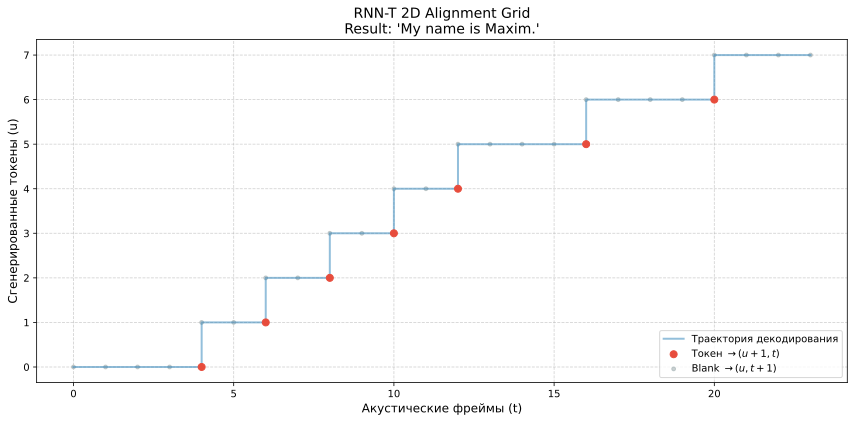

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.step(path[:, 0], path[:, 1], where='post', color='#2980b9', alpha=0.5, linewidth=2, label='Траектория декодирования')

ax.scatter(path[:, 0][path[:, 2] == 0], path[:, 1][path[:, 2] == 0],  color='#e74c3c', s=50, zorder=5, label=r'Токен $\to (u + 1, t)$')
ax.scatter(path[:, 0][path[:, 2] == 1], path[:, 1][path[:, 2] == 1],  color='#95a5a6', s=15, alpha=0.5, label=r'Blank $\to (u, t + 1)$')

ax.set_title(f"RNN-T 2D Alignment Grid\nResult: '{final_text}'", fontsize=14)
ax.set_xlabel("Акустические фреймы (t)", fontsize=12)
ax.set_ylabel("Сгенерированные токены (u)", fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()

### `RNN-T Forced Alignment`

Для решения задачи Forced Alignment можно использовать **Алгоритм Витерби**, который находит самый вероятный путь в 2D матрице переходов для Transducer loss. 

Альтернативой может служить soft разделение, которое оценивает **распределение длительности каждого символа через Forward-Backward переменные**.

Заметим, что Forward переменные $\alpha[t, u]$ оценивают вероятность прийти из узла $(0, 0)$ в узел $(t, u)$.

Аналогично можно посчитать Backward переменные $\beta[t, u]$, оценивающие вероятность прийти из узла $(T, U)$ в $(t, u)$.

Чтобы оценить вероятность, что в данном фрейме $t$ звучит данный токен $u$ можно посчитать вероятность, что путь выравнивания пройдёт через данный узел $\gamma[t, u]$. Очевидно:
$$
\gamma[t, u] = \frac{\alpha[t, u]\beta[t, u]}{P(Y | X)}
$$

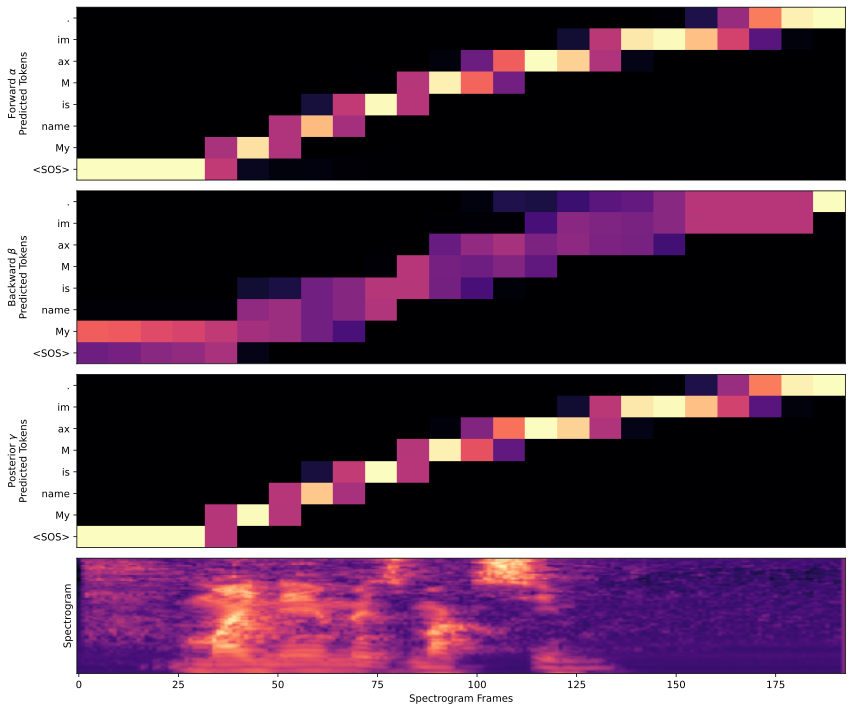

In [6]:
h_projs = []
for token_id in [None] + transcription_ids:
    token_id = torch.tensor([[token_id]], dtype=torch.long, device=device) if token_id is not None else None
    h_proj, state = model.decoder.predict(token_id, state=state, add_sos=False, batch_size=1)
    h_projs.append(model.joint.project_prednet(h_proj))

h_projs = torch.cat(h_projs, dim=1)  # [B, U + 1, H]
logits = model.joint.joint_after_projection(encoder_proj, h_projs)  # [1, T, U + 1, V]
log_probs = logits[0].log_softmax(dim=-1)  # [T, U + 1, V]

T, _, V = log_probs.shape
U = len(transcription_ids)

alpha = torch.zeros((T, U + 1), device=device)
for t in range(T):
    for u in range(U + 1):
        if t == 0 and u == 0:
            continue
        
        # Шаг ВПРАВО (t-1 -> t, выдача blank)
        log_p_t = alpha[t-1, u] + log_probs[t-1, u, model.decoding.blank_id] if t > 0 else torch.tensor(-1e9, device=device)
        
        # Шаг ВВЕРХ (u-1 -> u, выдача токена)
        log_p_u = alpha[t, u-1] + log_probs[t, u-1, transcription_ids[u-1]] if u > 0 else torch.tensor(-1e9, device=device)
        
        alpha[t, u] = torch.logaddexp(log_p_t, log_p_u)

beta = torch.zeros((T, U + 1), device=device)
for t in range(T - 1, -1, -1):
    for u in range(U, -1, -1):
        if t == T - 1 and u == U:
            continue
        
        # Шаг ВЛЕВО (t -> t+1, выдача blank)
        log_p_t = beta[t+1, u] + log_probs[t, u, model.decoding.blank_id] if t < T - 1 else torch.tensor(-1e9, device=device)
        
        # Шаг ВНИЗ (u -> u+1, выдача токена)
        log_p_u = beta[t, u+1] + log_probs[t, u, transcription_ids[u]] if u < U else torch.tensor(-1e9, device=device)
        
        beta[t, u] = torch.logaddexp(log_p_t, log_p_u)

posterior = alpha + beta

alpha_probs = torch.softmax(alpha, dim=1).cpu().detach().numpy() # [T, U + 1]
beta_probs = torch.softmax(beta, dim=1).cpu().detach().numpy() # [T, U + 1]
posterior_probs = torch.softmax(posterior, dim=1).cpu().detach().numpy() # [T, U + 1]

spectrogram = processed_audio[0].cpu().numpy() # [D, T_spec]

tokens = ["<SOS>"] + [model.tokenizer.ids_to_text([tid]) for tid in transcription_ids]

fig, axes = plt.subplots(4, 1, figsize=(12, 10), gridspec_kw={'height_ratios':[3, 3, 3, 2]})

# 1. Forward (Alpha)
axes[0].imshow(alpha_probs.T, aspect='auto', origin='lower', cmap='magma')
axes[0].set_ylabel(r"Forward $\alpha$""\nPredicted Tokens", fontsize=10)

# 2. Backward (Beta)
axes[1].imshow(beta_probs.T, aspect='auto', origin='lower', cmap='magma')
axes[1].set_ylabel(r"Backward $\beta$""\nPredicted Tokens", fontsize=10)

# 3. Posterior (Alpha * Beta)
axes[2].imshow(posterior_probs.T, aspect='auto', origin='lower', cmap='magma')
axes[2].set_ylabel(r"Posterior $\gamma$""\nPredicted Tokens", fontsize=10)

axes[3].imshow(spectrogram, aspect='auto', origin='lower', cmap='magma')
axes[3].set_ylabel("Spectrogram", fontsize=10)
axes[3].set_xlabel("Spectrogram Frames")

for i in range(3):
    axes[i].set_xticks([])
    axes[i].set_yticks(range(len(tokens)))
    axes[i].set_yticklabels(tokens)

axes[3].set_yticks([])
axes[3].set_xlabel("Spectrogram Frames")

plt.tight_layout()
plt.show()

Посмотрим на пример Forced Alignment для данной модели:

In [7]:
stride_sec = model.preprocessor.hop_length / model.cfg.sample_rate
subsampling_factor = int(torch.round(processed_len[0].float() / encoder_len[0].float()).item())

time_per_frame = stride_sec * subsampling_factor

for idx, token in enumerate(transcription_ids):
    idxs = np.where(posterior_probs[:, idx + 1] > 0.1)[0]
    start_frame, end_frame = np.min(idxs), np.max(idxs)
    print('{0}:\t{1} - {2}'.format(model.tokenizer.ids_to_text(token), start_frame, end_frame))

    start_time = int(start_frame * time_per_frame * sample_rate)
    end_time = int(end_frame * time_per_frame * sample_rate)
    chunk_audio = audio[start_time:end_time]

    display(Audio(chunk_audio, rate=sample_rate))

My:	4 - 6


name:	6 - 8


is:	7 - 10


M:	10 - 13


ax:	12 - 16


im:	16 - 21


.:	19 - 23


# `2. Encoder-Decoder`

Следующим логичным шагом является полный отказ от **Latent Alignment** и жесткой связи акустической и текстовой осей. В Latent Alignment модель использовала свойство монотонного alignment, что позволяет эффективно перебирать все возможные пути генерации.

Рассмотрим модели с **Implicit Alignment**, отказавшись от явного моделирования особенностей аудио домена (Blank токена, путей выравнивания). Рассмотрим задачу ASR как задачу связи произвольных доменов.

Архитектура Encoder-Decoder использовалась для связи различных доменов, в частности в задачах машинного перевода и Image Captioning. В итоге, к началу 2015 года сложился оптимальный рецепт Encoder-Decoder моделей:
* *Encoder* должен преобразовывать вход в **компактный, но разнообразный набор семантически наполненных векторов**. 
* *Decoder* должен обладать **глобальным контекстом** для обработки выхода Encoder, в частности путём использования механизма внимания. 

<table style="width: 100%; border-collapse: collapse; table-layout: fixed; font-family: Arial, sans-serif; line-height: 1.5;">
    <thead>
        <tr style="background-color: #f2f2f2;">
            <th style="border: 1px solid #ccc; padding: 10px; width: 33%;">
                <a href="https://arxiv.org/pdf/1409.3215" target="_blank" style="color: #0056b3; text-decoration: none; font-weight: bold;">
                    Sequence to Sequence Learning with Neural Networks
                </a> (2014)
            </th>
            <th style="border: 1px solid #ccc; padding: 10px; width: 33%;">
                <a href="https://arxiv.org/pdf/1411.4555" target="_blank" style="color: #0056b3; text-decoration: none; font-weight: bold;">
                    Show and Tell: A Neural Image Caption Generator
                </a> (2014)
            </th>
            <th style="border: 1px solid #ccc; padding: 10px; width: 33%;">
                <a href="https://arxiv.org/pdf/1502.03044" target="_blank" style="color: #0056b3; text-decoration: none; font-weight: bold;">
                    Show, Attend and Tell: Visual Attention
                </a> (2015)
            </th>
        </tr>
    </thead>
    <tbody>
        <!-- Ряд с картинками -->
        <tr>
            <td style="border: 1px solid #ccc; padding: 10px; text-align: center;">
                <img src="https://www.researchgate.net/profile/Gaetano-Rossiello-2/publication/314371682/figure/fig1/AS:469938172370946@1489053399496/Fig-An-example-of-encoder-decoder-paradigm-for-sequence-to-sequence-learning.png" style="width: 100%; border-radius: 5px;">
            </td>
            <td style="border: 1px solid #ccc; padding: 10px; text-align: center;">
                <img src="https://user-images.githubusercontent.com/17582508/48947066-35f00500-ef73-11e8-94f3-1859e8274d67.png" style="width: 100%; border-radius: 5px;">
            </td>
            <td style="border: 1px solid #ccc; padding: 10px; text-align: center;">
                <img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*A9VldrmKKP-YKJXf9Xtzag.jpeg" style="width: 100%; border-radius: 5px;">
            </td>
        </tr>
        <!-- Ряд: Решает -->
        <tr>
            <td style="border: 1px solid #ccc; padding: 10px; vertical-align: top;">
                Sequence-to-Sequence Машинный перевод. Преобразование одной последовательности в другую.
            </td>
            <td style="border: 1px solid #ccc; padding: 10px; vertical-align: top;">
                Image Captioning. Описание содержания картинки текстом.
            </td>
            <td style="border: 1px solid #ccc; padding: 10px; vertical-align: top;">
                Image Captioning. Описание содержания картинки текстом.
            </td>
        </tr>
        <!-- Ряд: Архитектура -->
        <tr style="background-color: #f9f9f9;">
            <td style="border: 1px solid #ccc; padding: 10px; vertical-align: top;">
                RNN Encoder-Decoder (две многослойные LSTM).
            </td>
            <td style="border: 1px solid #ccc; padding: 10px; vertical-align: top;">
                Комбинация CNN и RNN.
            </td>
            <td style="border: 1px solid #ccc; padding: 10px; vertical-align: top;">
                CNN + Attention + RNN. Использование карт признаков для внимания.
            </td>
        </tr>
        <!-- Ряд: Энкодер -->
        <tr>
            <td style="border: 1px solid #ccc; padding: 10px; vertical-align: top;">
                <strong>Энкодер:</strong> LSTM. Принимает входную последовательность слов и сжимает её в фиксированный вектор контекста.
            </td>
            <td style="border: 1px solid #ccc; padding: 10px; vertical-align: top;">
                <strong>Энкодер:</strong> Глубокая CNN. Извлекает один вектор признаков из всего изображения.
            </td>
            <td style="border: 1px solid #ccc; padding: 10px; vertical-align: top;">
                <strong>Энкодер:</strong> Глубокая CNN. Извлекает набор векторов для разных областей.
            </td>
        </tr>
        <!-- Ряд: Декодер -->
        <tr style="background-color: #f9f9f9;">
            <td style="border: 1px solid #ccc; padding: 10px; vertical-align: top;">
                <strong>Декодер:</strong> LSTM. Генерирует выходную последовательность, используя только финальный вектор энкодера.
            </td>
            <td style="border: 1px solid #ccc; padding: 10px; vertical-align: top;">
                <strong>Декодер:</strong> LSTM. Инициализируется признаками из CNN и предсказывает слова по одному.
            </td>
            <td style="border: 1px solid #ccc; padding: 10px; vertical-align: top;">
                <strong>Декодер:</strong> LSTM с Attention. На каждом шаге "взвешивает" векторы из CNN, выбирая нужную часть картинки.
            </td>
        </tr>
    </tbody>
</table>

## `2.1. Listen, Attend and Spell: Attention-based Encoder-Decoder`

Реализацией этого подхода является [Listen, Attend and Spell](https://arxiv.org/pdf/1508.01211) архитектура — **Attention-based Encoder-Decoder (AED)**:

![](https://miro.medium.com/v2/resize:fit:700/1*LRPyLHYjoX_gk8dCjN2hQg.png)

Архитектура состоит из двух логических блоков:

**I. Listen (Encoder)**

Задача энкодера — преобразовать сырую спектрограмму $X = (\mathbf{x}_1, \dots, \mathbf{x}_T)$ в плотное высокоуровневое представление $H^{\text{enc}} = (\mathbf{h}^{\text{enc}}_1, \dots, \mathbf{h}^{\text{enc}}_{M})$. 
В оригинальной архитектурой для этого использовалась пирамидальная BiLSTM. В современных реализациях это стандартный Conformer/Transformer энкодер.

Дискуссия о оптимальной частоте дискретизации и числе фреймов для CTC/Transducer моделей остаётся актуальной и для Encoder-Decoder архитектуры. В ранних моделях большие входные длины непозволительно замедляли сходимость, тогда как в современных моделях основным ограничением является скорость инференса, которая усугубляется квадратичной сложностью Attention внутри Encoder. Поэтому энкодер **обязательно** включает слои субдискретизации (Subsampling / Pyramidal pooling), например, свертки со страйдом, сжимая ось времени в $4$-$8$ раз ($M \ll T$).

**II. Attend and Spell (Decoder)**

Это авторегрессионная языковая модель, обусловленная на аудио. На каждом шаге генерации $i$ декодер выполняет следующие действия:

1. **Attend (Cross-Attention):** Декодер смотрит на свое текущее скрытое состояние $\mathbf{h}^{\text{dec}}_{i-1}$ и вычисляет веса внимания $\alpha_{i, j}$ ко **всем** кадрам энкодера $\mathbf{h}^{\text{enc}}_j$. Оригинальная статья использовала аддитивный attention, но сейчас используется Scaled Dot-Product Attention:
   
   $$ \mathbf{Q}_i = \mathbf{h}^{\text{dec}}_{i-1} \mathbf{W}^Q, \quad \mathbf{K} = H^{\text{enc}} \mathbf{W}^K, \quad \mathbf{V} = H^{\text{enc}} \mathbf{W}^V $$
   $$ \alpha_{i} = \text{Softmax}\left( \frac{\mathbf{Q}_i \mathbf{K}^T}{\sqrt{d}} \right) $$
   
   Вектор контекста $\mathbf{c}_i$ собирается как взвешенная сумма акустических кадров:
   $$ \mathbf{c}_i = \sum_{j=1}^{M} \alpha_{i, j} \mathbf{v}_j $$

2. **Spell (Generate):** Полученный акустический контекст $\mathbf{c}_i$ объединяется с информацией о предыдущем сгенерированном токене $y_{i-1}$ для предсказания распределения следующего токена:
   
   $$ P(y_i \mid y_{<i}, X) = \text{Softmax}\Big( \text{MLP}( [\mathbf{h}^{\text{dec}}_{i-1}; \mathbf{c}_i] ) \Big) $$

Для более современных AED Decoder может быть реализован через любую авторегрессионную модель, например, **Transformer c Self- и Cross- Attention**.

<b style='color:red;'>В CTC и Transducer выравнивание было строго монотонным по построению (нельзя вернуться назад во времени). Гарантирует ли Cross-Attention монотонность выравнивания в AED?</b>

<details><summary>Ответ:</summary>>> 

**Нет, не гарантирует.** Механизм внимания может смотреть на любой кадр аудио в любой момент времени. Обычно в процессе обучения модель *сама выучивает* диагональную (монотонную) матрицу внимания, так как речь линейна. 
Однако при инференсе на шумных данных матрица теряет диагональную структуру, модель начинает смотреть на одни и те же кадры (генерируя бесконечные повторения слов) или пропускать куски аудио (deletions).

</details>

## `2.2. Обучение`

Обучение такой модели происходит в обычном end-to-end supervised режиме:
$$
\mathfrak{L} = -\log P(Y | X) \longrightarrow \min
$$

<table style="width: 100%; border-collapse: collapse; table-layout: fixed; font-family: Arial, sans-serif;">
    <tbody>
        <!-- Ряд с картинками -->
        <tr>
            <td style="border: 1px solid #ccc; padding: 10px; text-align: center; background: white;">
                <img src="https://colinraffel.com/blog/images/mad/las_alignments.png" style="width: 100%; height: auto;">
            </td>
            <td style="border: 1px solid #ccc; padding: 10px; text-align: center; background: white;">
                <img src="https://www.hankcs.com/wp-content/uploads/2017/07/2017-07-01_16-45-01.png" style="width: 100%; height: auto;">
                <img src="https://www.hankcs.com/wp-content/uploads/2017/07/2017-07-01_16-45-28.png" style="width: 100%; height: auto;">
            </td>
            <td style="border: 1px solid #ccc; padding: 10px; text-align: center; background: white;">
                <img src="https://www.hankcs.com/wp-content/uploads/2017/07/hankcs.com-2017-07-01-%E4%B8%8B%E5%8D%884.25.45.png" style="width: 150%; height: auto;">
            </td>
        </tr>
        <!-- Ряд с описанием того, что происходит на изображениях -->
        <tr>
            <td style="border: 1px solid #ccc; padding: 15px; vertical-align: top; font-size: 0.95em; line-height: 1.4;">
                <b>Монотонное выравнивание:</b> Модель корректно сопоставляет шаги времени аудио и символы. Заметно размытие внимания на словах <i>woodchuck</i> и <i>chuck</i> из-за их акустического сходства, но модель успешно сохраняет общую последовательность без использования априорных знаний о языке.
            </td>
            <td style="border: 1px solid #ccc; padding: 15px; vertical-align: top; font-size: 0.95em; line-height: 1.4;">
                <b>Вариативность написания:</b> LAS способна генерировать разные варианты транскрипции для одного сигнала. Модель на ходу адаптирует матрицу внимания, распределяя веса по аудио-фреймам в зависимости от того, какой символ (краткий или полный вариант) она выбрала для генерации в данный момент.
            </td>
            <td style="border: 1px solid #ccc; padding: 15px; vertical-align: top; font-size: 0.95em; line-height: 1.4;">
                <b>Путаница при повторах:</b> Фраза <i>"cancel cancel cancel"</i> демонстрирует «параллельные диагонали». Content-based механизм внимания, может теряться в повторяющихся акустических паттернах. Тем не менее, LAS успешно справляется с задачей, выдавая правильную гипотезу даже при наличии визуальных артефактов в матрице внимания.
            </td>
        </tr>
    </tbody>
</table>

Кроме того, можно добиться улучшения сходимости и семантического качества скрытых состояний Encoder путём совместного обучения гибридной CTC/Attention архитектуры ([Hybrid CTC/Attention Architecture for End-to-End Speech
Recognition](https://www.merl.com/publications/docs/TR2017-190.pdf)), которая объединяет CTC и авторегрессионный лосс:

$$
\mathfrak{L}_{MOL} = -\lambda \log P_{CTC}(Y|X) - (1 - \lambda) \log P(Y | X) \longrightarrow \min
$$

Такой процесс обучения позволяет смешивать CTC и авторегрессионные вероятности во время инференса, что приводит к улучшенным путям alignment:

<img src="./MOL-Attention.svg" style="width: 70%; height: auto;">

**Более того, для современных моделей можно выполнять SSL предобучение Encoder и Decoder модели на неразмеченных аудио и текстах.**

## `2.3. Teacher Forcing`

Архитектуры типа Transducer и Encoder-Decoder отказываются от свойства условной независимости, вводя авторегрессионную зависимость: вероятность предсказания следующего токена $P(y_i \mid y_{<i}, X)$ зависит от предыдущих токенов $y_{<i}$.

**При обучении таких моделей основной вопрос: на какую именно историю $y_{<i}$ опираться при вычислении лосса для шага $i$?**

В стандартном режиме обучения используется **Teacher Forcing**. Это означает, что для вычисления условной вероятности $P(y_i \mid y_{<i}, X)$ в декодер (или Prediction Network в Transducer) подаётся **Ground Truth** префикс из обучающей выборки $y_{<i}^*$.

Лосс для всей последовательности вычисляется как:
$$
\mathfrak{L} = -\log P_{\theta}(Y^* | X) = -\sum_{i=1}^{N} \log P(y_i^* \mid y_{<i}^*, X)
$$

**Преимущества Teacher Forcing:**
1.  **Стабильность и скорость обучения:** Модель на каждом шаге получает корректный контекст, что позволяет градиентам быть стабильными.
2.  **Параллелизация:** Поскольку вся истинная последовательность $Y^*$ известна заранее, можно вычислить все скрытые состояния декодера для всех шагов $i=1, \dots, N$ за один параллельный проход (например, используя Causal Mask в Transformer-декодере).

### `Exposure Bias`

На этапе инференса доступ к истинному тексту отсутствует. Декодер вынужден опираться на свои **собственные предыдущие предсказания** $\hat{y}_{<i}$.

$$
\hat{y}_i = \arg\max_{y \in V} P(y \mid \hat{y}_{<i}, X)
$$

Возникает несоответствие между обучением и инференсом, также известное как **Exposure Bias**:
*   Во время обучения модель **никогда не видит** своих собственных ошибок.
*   Во время инференса любая ошибка (например, $\hat{y}_3 \neq y_3^*$) приводит к тому, что на следующем шаге модель получает на вход искаженный контекст, которого она не видела при обучении. Это может привести к каскадному накоплению ошибок.

Степень тяжести зависит от баланса влияния акустической и языковой частей модели.

1.  **RNN-T:** Проблема локализована в **Prediction Network**. Encoder остается независимым и на каждом шаге $t$ может скорректировать ошибку языка акустическим сигналом.
2.  **Encoder-Decoder:** Языковая (Self-Attention) и акустическая (Cross-Attention) части смешаны внутри декодера. Ошибка в сгенерированном токене приводит к формированию неверного `Query` для Cross-Attention, заставляя модель смотреть на неправильную часть аудио.
3.  **Decoder-Only:** Языковая часть доминирует. Акустика — лишь часть промпта. Модель наиболее склонна игнорировать звук при ошибке в текстовом контексте.

### `Способы борьбы с Exposure Bias`

* **Scheduled Sampling:** На этапе обучения с некоторой вероятностью $p$ вместо истинного токена $y_{i-1}^*$ в декодер подаётся предсказание модели с прошлого шага $\hat{y}_{i-1}$. Вероятность $p$ обычно растет от 0 до 1 в процессе обучения.
* **Beam Search:** Вместо одного жадного пути генерируется $K$ гипотез, что делает модель более устойчивой к единичным ошибкам.
* **Sequence-Level Training (MWER):** Вместо обычной функции потерь модель дообучается оптимизировать метрику на уровне всей последовательности (например, WER), заставляя модель учиться на своих ошибках.

## `2.4. Декодирование`

Интересно, что декодинг можно выполнять аналогично всем предыдущим архитектурам, с использованием Beam Search, Shallow Fusion и Rescoring, получая значительные улучшения ([An analysis of incorporating an external language model into a sequence-to-sequence model
](https://arxiv.org/pdf/1712.01996)).

<div style="display: flex; flex-direction: row; align-items: flex-start; justify-content: space-between; gap: 20px; padding: 10px; font-family: sans-serif;">
    <!-- 1. Левая часть: Картинка архитектуры -->
    <div style="flex: 1; text-align: center; min-width: 250px;">
        <div style="padding: 10px; border: 1px solid #ddd; border-radius: 4px; background: white;">
            <img src="https://gentlesnow.github.io/images/DL-images/paper-007-02.png" style="width: 100%; height: auto;">
        </div>
    </div>
    <!-- 2. Центральная часть: Первая таблица (WSJ task) -->
    <div style="flex: 1.2; min-width: 300px;">
        <table style="border-collapse: collapse; width: 100%; border-top: 2px solid black; border-bottom: 2px solid black; font-family: serif; color: black; font-size: 1.1em;">
            <thead>
                <tr style="border-bottom: 1px solid black;">
                    <th style="padding: 8px; text-align: left;">System</th>
                    <th style="padding: 8px; text-align: center;">Dev</th>
                    <th style="padding: 8px; text-align: center;">Test</th>
                </tr>
            </thead>
            <tbody>
                <tr>
                    <td style="padding: 6px 8px; text-align: left;">LAS-G</td>
                    <td style="padding: 6px 8px; text-align: center;">13.0</td>
                    <td style="padding: 6px 8px; text-align: center;">10.3</td>
                </tr>
                <tr>
                    <td style="padding: 6px 8px; text-align: left;">LAS-G + 20-GRAM-G</td>
                    <td style="padding: 6px 8px; text-align: center;">10.3</td>
                    <td style="padding: 6px 8px; text-align: center;">7.7</td>
                </tr>
                <tr>
                    <td style="padding: 6px 8px; text-align: left;">LAS-G + 3-GRAM-W</td>
                    <td style="padding: 6px 8px; text-align: center;">10.0</td>
                    <td style="padding: 6px 8px; text-align: center;">7.6</td>
                </tr>
                <tr>
                    <td style="padding: 6px 8px; text-align: left;">LAS-G + RNN-G</td>
                    <td style="padding: 6px 8px; text-align: center;">9.3</td>
                    <td style="padding: 6px 8px; text-align: center;">6.9</td>
                </tr>
            </tbody>
        </table>
        <!-- Подпись для 1-й таблицы -->
        <div style="font-size: 0.8em; color: #333; margin-top: 10px; background: #f9f9f9; padding: 10px; border-radius: 4px;">
            • <b>LAS-G</b> — Baseline<br>
            • <b>LAS-G + 20-GRAM-G</b> — Shallow Fusion<br>
            • <b>LAS-G + 3-GRAM-W</b> — Shallow Fusion<br>
            • <b>LAS-G + RNN-G</b> — Shallow Fusion
        </div>
    </div>
    <!-- 3. Правая часть: Новая таблица (Voice Search task) -->
    <div style="flex: 1.5; min-width: 350px;">
        <table style="border-collapse: collapse; width: 100%; border-top: 2px solid black; border-bottom: 2px solid black; font-family: serif; color: black; font-size: 1.1em;">
            <thead>
                <tr style="border-bottom: 1px solid black;">
                    <th style="padding: 8px; text-align: left;">System</th>
                    <th style="padding: 8px; text-align: center;">Dev</th>
                    <th style="padding: 8px; text-align: center;">Test</th>
                    <th style="padding: 8px; text-align: center;">LM size</th>
                </tr>
            </thead>
            <tbody>
                <tr>
                    <td style="padding: 4px 8px; text-align: left;">LAS-G</td>
                    <td style="padding: 4px 8px; text-align: center;">9.5</td>
                    <td style="padding: 4px 8px; text-align: center;">7.7</td>
                    <td style="padding: 4px 8px; text-align: center;">0GB</td>
                </tr>
                <tr style="border-bottom: 1px solid #ccc;">
                    <td style="padding: 4px 8px; text-align: left;">LAS-WP</td>
                    <td style="padding: 4px 8px; text-align: center;">9.2</td>
                    <td style="padding: 4px 8px; text-align: center;">7.7</td>
                    <td style="padding: 4px 8px; text-align: center;">0GB</td>
                </tr>
                <tr>
                    <td style="padding: 4px 8px; text-align: left;">LAS-WP + PRODLM1</td>
                    <td style="padding: 4px 8px; text-align: center;">8.8</td>
                    <td style="padding: 4px 8px; text-align: center;">7.4</td>
                    <td style="padding: 4px 8px; text-align: center;">2GB</td>
                </tr>
                <tr style="border-bottom: 1px solid #ccc;">
                    <td style="padding: 4px 8px; text-align: left;">LAS-WP + PRODLM2</td>
                    <td style="padding: 4px 8px; text-align: center;">8.7</td>
                    <td style="padding: 4px 8px; text-align: center;">7.2</td>
                    <td style="padding: 4px 8px; text-align: center;">80GB</td>
                </tr>
                <tr>
                    <td style="padding: 4px 8px; text-align: left;">LAS-WP + RNN-WP</td>
                    <td style="padding: 4px 8px; text-align: center;">8.4</td>
                    <td style="padding: 4px 8px; text-align: center;">7.0</td>
                    <td style="padding: 4px 8px; text-align: center;">1.1GB</td>
                </tr>
                <tr>
                    <td style="padding: 4px 8px; text-align: left;">LAS-WP + RNN-WP + PRODLM2</td>
                    <td style="padding: 4px 8px; text-align: center;">8.4</td>
                    <td style="padding: 4px 8px; text-align: center;">7.0</td>
                    <td style="padding: 4px 8px; text-align: center;">81.1GB</td>
                </tr>
            </tbody>
        </table>
        <!-- Подпись для 2-й таблицы -->
        <div style="font-size: 0.8em; color: #333; margin-top: 10px; background: #f9f9f9; padding: 10px; border-radius: 4px;">
            • <b>LAS-G</b> — Baseline (Базовая модель на графемах)<br>
            • <b>LAS-WP</b> — Baseline (Базовая модель на частях слов)<br>
            • <b>LAS-WP + PRODLM1</b> — Shallow Fusion<br>
            • <b>LAS-WP + PRODLM2</b> — Rescoring<br>
            • <b>LAS-WP + RNN-WP</b> — Shallow Fusion<br>
            • <b>LAS-WP + RNN-WP + PRODLM2</b> — Shallow Fusion + Rescoring
        </div>
    </div>
</div>

## `2.5. OpenAI Whisper`

Долгое время считалось, что AED модели, будучи data-hungry, уступают CTC и Transducer на малых объемах данных и требуют качественных аудио.

[Whisper](https://arxiv.org/pdf/2212.04356) использует стандартную Encoder-Decoder (Transformer-Transformer) архитектуру, однако за счёт масштабирования данных получилось достичь высокого качества не только на in-domain валидации, но и на out-domain.

1. **Weak Supervision:** Whisper v1 и v2 были обучены на **680 000 часах** аудио, собранного из интернета. **Whisper v3**, обучен на **5 000 000 часов** (1 млн часов weakly labeled + 4 млн pseudo-labeled аудио).
  
   *Так как данные не очищались вручную там есть шум, музыка, смех, опечатки в тексте и транскрипции, сгенерированные другими ASR-системами.* 
4. **Мультизадачность через токены:** AED модель обучаясь на next-token prediction решает сразу множество задач: определение языка, транскрибацию, перевод на английский язык и предсказание таймстемпов.
   
Для этого используется специальный формат промптов на входе в декодер:
$$ \langle|\text{startoftranscript}|\rangle \langle|\text{ru}|\rangle \langle|\text{transcribe}|\rangle \langle|\text{notimestamps}|\rangle \text{ Привет, мир!} \langle|\text{endoftext}|\rangle $$

<div style="display: flex; flex-direction: row; align-items: flex-start; justify-content: space-between; gap: 20px; padding: 10px; font-family: sans-serif;">
    <div style="flex: 1; text-align: center; min-width: 250px;">
        <div style="padding: 10px; border: 1px solid #ddd; border-radius: 4px; background: white;">
            <img src="https://raw.githubusercontent.com/openai/whisper/main/approach.png" style="width: 90%; height: auto;">
        </div>
    </div>
    <div style="flex: 1; text-align: center; min-width: 250px;">
        <div style="padding: 10px; border: 1px solid #ddd; border-radius: 4px; background: white;">
            <img src="https://ar5iv.labs.arxiv.org/html/2212.04356/assets/x2.png" style="width: 70%; height: auto;">
        </div>
    </div>
</div>

Из существенных недостатков, которые, впрочем, присущи любым Encoder-Decoder моделям:
1. **Implicit Alignment:** У модели нет Blank-токена, чтобы поглощать тишину. Когда идет долгая пауза, Cross-Attention ищет фонетические паттерны в фоновом шуме.
2. **Сильная языковая модель:** Декодер Whisper — это мощная LLM. Если акустический контекст слабый (тишина), языковая модель начинает генерировать грамматически связный текст, исходя из предыдущего контекста.
3. **Грязные обучающие данные:** В обучающей выборке Whisper часто встречались субтитры к видео, где во время тишины на экране были надписи вроде `[Музыка играет]`, `[Смех]`, `[Аплодисменты]` или даже реклама. Модель выучила эту корреляцию и часто воспроизводит её.

**Эвристики для Long-form транскрипции:**

Так как рецептивное поле Whisper ограничено 30 секундами, для длинных аудио используется алгоритм скользящего окна. Чтобы бороться с галлюцинациями и зацикливаниями декодера, авторы предложили несколько эвристик в процедуре Beam Search decoding:
* Модель откатывается назад и **повышает Temperature** (с $0.0$ до $0.2, 0.4 \dots 1.0$), что заставляет ее выйти из локального минимума и сгенерировать другой вариант:
    * Если средний `log probability` предсказанных токенов падает ниже `-1.0` (модель не уверена).
    * Или если степень сжатия сгенерированного текста алгоритмом `gzip` превышает `2.4` (модель зациклилась и повторяет одну и ту же фразу, так как повторяющийся текст сжимается очень хорошо).
* Также используется **Voice Activity Detection (VAD)**: если вероятность токена `<|nospeech|>` превышает $0.6$, модель пропускает сегмент.

Более того, для длинных аудио желательно отделять речь от длинных сегментов тишины с использованием сторонних VAD моделей.

<table class="whisper-table">
    <thead>
        <tr>
            <th></th>
            <th class="vertical-text border-left">TED-LIUM3</th>
            <th class="vertical-text">Meanwhile</th>
            <th class="vertical-text">Kincaid46</th>
            <th class="vertical-text">Rev16</th>
            <th class="vertical-text">Earnings-21</th>
            <th class="vertical-text">Earnings-22</th>
            <th class="vertical-text">CORAAL</th>
            <th class="vertical-text border-left">Average</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Greedy decoding only</td>
            <td class="border-left">3.95</td>
            <td>5.16</td>
            <td>9.69</td>
            <td>11.7</td>
            <td>10.7</td>
            <td>14.0</td>
            <td>22.0</td>
            <td class="border-left">11.0</td>
        </tr>
        <tr>
            <td>+ Beam search</td>
            <td class="border-left">4.16</td>
            <td>5.71</td>
            <td>9.42</td>
            <td>11.5</td>
            <td>10.2</td>
            <td>13.4</td>
            <td>20.0</td>
            <td class="border-left">10.6</td>
        </tr>
        <tr>
            <td>+ Temperature fallback</td>
            <td class="border-left">4.16</td>
            <td>5.71</td>
            <td>9.42</td>
            <td>11.5</td>
            <td>10.2</td>
            <td>13.4</td>
            <td>20.0</td>
            <td class="border-left">10.6</td>
        </tr>
        <tr>
            <td>+ Voice activity detection</td>
            <td class="border-left">3.56</td>
            <td class="bold-val">4.61</td>
            <td>9.45</td>
            <td>11.4</td>
            <td>10.1</td>
            <td>13.2</td>
            <td>19.4</td>
            <td class="border-left">10.2</td>
        </tr>
        <tr>
            <td>+ Previous text conditioning</td>
            <td class="border-left"><span class="bold-val">3.42</span></td>
            <td>6.16</td>
            <td>8.72</td>
            <td class="bold-val">11.0</td>
            <td class="bold-val">9.63</td>
            <td>13.3</td>
            <td class="bold-val">18.1</td>
            <td class="border-left">10.0</td>
        </tr>
        <tr>
            <td>+ Initial timestamp constraint</td>
            <td class="border-left">3.51</td>
            <td>5.26</td>
            <td class="bold-val">8.41</td>
            <td>11.5</td>
            <td>9.73</td>
            <td class="bold-val">12.6</td>
            <td>19.1</td>
            <td class="border-left">10.0</td>
        </tr>
    </tbody>
</table>

### `Prompting`

Так как декодер Whisper является авторегрессионной языковой моделью, он способен к **In-Context Learning через промптинг**.

В традиционных ASR-моделях (например, на базе CTC или RNN-T) для добавления специфичных терминов или изменения стиля текста необходимо использовать внешние языковые модели (Shallow Fusion) или дообучать сеть. В Whisper управление поведением модели осуществляется путем подачи текстового префикса (промпта) прямо на вход декодера перед началом генерации.

Промпт — это последовательность токенов $Y_{\text{prompt}}$, которая помещается в контекстное окно декодера **до** специальных управляющих токенов. 

Формат входа декодера принимает следующий вид:
$$ Y_{\text{prompt}} \oplus \langle|\text{startoftranscript}|\rangle \oplus \langle|\text{lang}|\rangle \oplus \langle|\text{task}|\rangle \oplus \langle|\text{notimestamps}|\rangle \dots $$

Таким образом, на шаге генерации $i$ модель оценивает распределение следующего токена с учетом не только аудио $X$ и уже сгенерированного текста $y_{<i}$, но и заданного префикса:
$$ P(y_i \mid Y_{\text{prompt}}, y_{<i}, X) $$

Контекстное окно декодера Whisper ограничено. Если длина промпта превышает половину окна, старые токены промпта отбрасываются, чтобы оставить место для генерации транскрипции.

**Основные сценарии использования:**

1. **Long-form транскрипция:**
   Whisper обрабатывает аудио фрагментами по $30$ секунд. Если слово разрывается на границе чанков, модель может его потерять. Связность текста можно обеспечить передавая транскрипцию предыдущего $30$-секундного окна в качестве промпта для следующего.

2. **Доменная адаптация и словарь:**
   Если в аудио произносится редкое имя или аббревиатура (например, *«DALL-E»* или *«PyTorch»*), модель может транскрибировать их фонетически (*«дали»*, *«пайторч»*). Передав в промпте фразу `"Глоссарий: DALL-E, PyTorch, ChatGPT."`, вероятность генерации этих токенов искуственно повышается.

3. **Стилистика и форматирование:**
   Whisper умеет имитировать стиль промпта. 
   * *Пунктуация:* Если промпт написан строчными буквами и без запятых (`"привет как дела это тестовый промпт"`), модель продолжит транскрипцию в таком же стиле. Если передать идеально пунктуированный текст, модель будет расставлять знаки препинания.
   * *Слова-паразиты (Disfluencies):* По умолчанию Whisper обучен игнорировать "э-э-э" и "м-м-м". Чтобы заставить модель транскрибировать речь дословно (verbatim), можно использовать промпт: `"Ну, э-э-э, давай подумаем, хм... Окей, вот что я думаю."`.

<b style='color:red;'>Что произойдет, если мы передадим Whisper аудио на русском языке, а в качестве промпта укажем длинный текст на английском?</b>

<details><summary>Ответ:</summary>>> 

Поскольку декодер — это сильная LLM, английский промпт может "перевесить" русский аудиосигнал. В результате модель с высокой вероятностью либо **начнет переводить** русскую речь на английский, либо начнёт галлюцинировать, проигнорировав аудио и начав продолжать английский текст из промпта. Именно поэтому промпт всегда должен соответствовать языку аудиодорожки.
</details>

### `Whisper Inference`

In [8]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration

device = torch.device('cuda', 0)

processor = WhisperProcessor.from_pretrained("openai/whisper-tiny")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-tiny", attn_implementation="eager")
model.to(device).eval()

WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 384, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(384, 384, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 384)
      (layers): ModuleList(
        (0-3): 4 x WhisperEncoderLayer(
          (self_attn): WhisperAttention(
            (k_proj): Linear(in_features=384, out_features=384, bias=False)
            (v_proj): Linear(in_features=384, out_features=384, bias=True)
            (q_proj): Linear(in_features=384, out_features=384, bias=True)
            (out_proj): Linear(in_features=384, out_features=384, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
          (fin

In [9]:
audio_path = 'audio_test.wav' 

audio, sample_rate = soundfile.read(audio_path, dtype=np.float32)
audio_tensor = torch.tensor(audio).unsqueeze(0)

resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000)

audio_tensor = resampler(audio_tensor)

input_features = processor(audio_tensor.squeeze(0), sampling_rate=16000, return_tensors="pt").input_features.to(device)
input_features.shape

torch.Size([1, 80, 3000])

In [10]:
forced_decoder_ids = processor.get_decoder_prompt_ids(language="english", task="transcribe")

with torch.no_grad():
    outputs = model.generate(
        input_features,
        forced_decoder_ids=forced_decoder_ids,
        return_dict_in_generate=True,
        output_attentions=True,
        max_new_tokens=50
    )

generated_ids = outputs.sequences
transcription = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
transcription

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


'<|startoftranscript|><|en|><|transcribe|><|notimestamps|> My name is Maxim.<|endoftext|>'

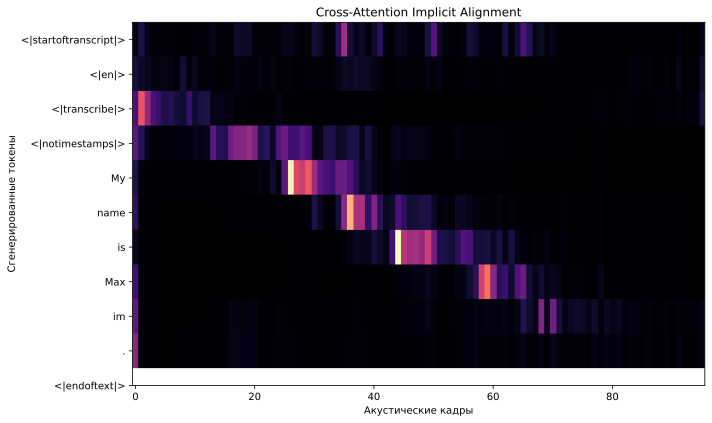

In [12]:
attention = outputs.cross_attentions  # [num_tokens, num_layers, batch_size, num_heads, current_decoder_seq_length, encoder_seq_length]
attention = torch.vstack([
    outputs.cross_attentions[tidx][-1].squeeze(0).mean(dim=0)
    for tidx in range(len(attention))
])  # [decoder_seq_length, encoder_seq_length]

# 50 фреймов в секунде (1000ms / 20ms)
valid_frames = int(audio_tensor.shape[1] / 16000 * 50)
attention = attention[:, :valid_frames]

decoded_tokens = [processor.decode([token]) for token in generated_ids[0]]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(attention.cpu(), aspect='auto', origin='upper', cmap='magma')

ax.set_yticks(np.arange(len(decoded_tokens)))

ax.set_yticklabels(decoded_tokens)
ax.set_xlabel("Акустические кадры")
ax.set_ylabel("Сгенерированные токены")
ax.set_title("Cross-Attention Implicit Alignment")

fig.tight_layout()
plt.show()

# `3. Streaming ASR`

До сих пор мы предполагали во всех моделях, что аудиозапись уже полностью загружена в память, и нейросеть имеет доступ ко всей фразе от начала до конца. Это позволяет достичь максимального качества , но делает такие системы непригодными для интерактивного взаимодействия.

Для голосовых ассистентов, диктовки на смартфонах или генерации live-субтитров критически важна **низкая задержка**. Модель должна начать выдавать текст сразу, как только пользователь начал говорить. Такой режим работы называется **Real-time (Streaming) ASR**.

В потоковом режиме аудио поступает в систему небольшими чанками (например, по $20$–$50$ мс). Задача ASR — на лету обновлять текстовую гипотезу. Этот процесс порождает так называемое **Partial Recognition**, когда по мере поступления новых звуков модель может исправлять окончания слов.

![](Partial-Recognition.svg)

Главным параметром, определяющим задержку системы, является **Lookahead**.
В речи текущая фонема сильно зависит от того, какой звук идет *после* нее из-за эффекта коартикуляции. Чтобы уверенно классифицировать звук в момент времени $t$, модели необходимо посмотреть на фреймы $t+1, t+2, \dots, t+R$. Размер этого окна $R$ (в миллисекундах) и есть **Lookahead**.

Для оценки Streaming ASR моделей обычно рассматривают зависимость метрики качества, например, WER, от величины Lookahead (размера **Chunk Size**).

## `3.1. Адаптация энкодера`

Стандартная архитектура энкодеров, например, **Conformer** не подходит для работы в потоковом режиме, так как скрытое представление $\mathbf{h}_t$ на выходе зависит от входов из будущего. Это различие между обучением в offline режиме и online инференсом **не позволяет переиспользовать offline модели для Streaming ASR.** 

**Для того, чтобы модель могла работать в online режиме все её компоненты должны быть каузальными, то есть выход модели зависит только от прошлого.**

В Conformer есть два некаузальных компонента, которые нужно модифицировать:

**I. Convolution Module**

Обычная 1D-свертка с окном размера $K$ центрируется по текущему фрейму. Чтобы вычислить $\mathbf{h}_t$, она берет информацию от $t - \lfloor K/2 \rfloor$ до $t + \lfloor K/2 \rfloor$. Это создает Lookahead, равный половине ядра свертки на *каждом слое*. При $16$ слоях накопленная задержка составит секунды!

**Решение:** Использование **Causal Convolutions**. Мы сдвигаем padding так, чтобы свертка опиралась только на историю: от $t - K + 1$ до $t$.

![](https://www.researchgate.net/profile/Dan-Kondratyuk/publication/350311379/figure/fig1/AS:1019437058646017@1620064143175/Standard-Convolution-vs-Causal-Convolution-The-figure-illustrates-the-effective.ppm)

**II. Multi-Head Self-Attention Module**

В базовом трансформере матрица внимания (Full-Context Attention) является плотной: каждый фрейм смотрит на каждый. Для стриминга мы должны наложить маску на логиты внимания до применения Softmax.

Существует несколько подходов к маскированию:

* **Causal Attention:** Маскирование будущего: фрейм $i$ может смотреть только на $j \le i$.

  *Минус:* Катастрофическое падение качества, так как модель теряет информацию о коартикуляции.

* **Restricted Attention (с заданным Lookahead):** Модель может заглядывать вперед на строго заданное число фреймов $R$ (правый контекст) и назад на $L$ фреймов (левый контекст).
  
* **Chunk-wise Attention:**
  Входной поток жестко нарезается на непересекающиеся блоки фиксированного размера (например, по $300$ мс). Внутри блока Attention вычисляется полностью. Текущий чанк также может смотреть на закэшированные представления из *предыдущих* чанков. Модель накапливает чанк, создавая фиксированный Lookahead = размер чанка.

![](Casual-Attention.svg)

<b style='color:red;'>Как размер чанка (Chunk size) в Chunk-wise Attention влияет на метрику Real-Time Factor?</b>

<details><summary>Ответ:</summary>>> 

Увеличение размера чанка **уменьшает RTF**, так как GPU лучше утилизируется на больших матричных умножениях по сравнению с вызовом вычислений каждый фрейм. 
Однако при этом **растет Latency**. Пользователю придется ждать, пока накопится полный чанк аудио, прежде чем на экране появится новое слово. 

</details>

## `3.2. Accuracy vs. Lookahead`

Ограничение правого контекста естественным образом ухудшает  качество распознавания ([Stateful Conformer with Cache-based Inference for Streaming Automatic Speech Recognition](https://arxiv.org/pdf/2312.17279)):

| Decoder | Architecture Type | Approach | 0ms | 40ms | 240ms | 520ms | 680ms | 1360ms |
|:---|:---|:---|:---:|:---:|:---:|:---:|:---:|:---:|
| **CTC** | Hybrid | Regular | 10.6 | - | - | - | 8.3 | 7.9 |
| | Hybrid | Chunk-aware | 10.6 | 10.1 | 8.8 | 8.4 | 8.0 | 7.1 |
| | Non-hybrid | Chunk-aware | 10.8 | 10.3 | 8.9 | - | 8.1 | - |
| | | | | | | | | |
| **RNNT** | Hybrid | Regular | 9.5 | - | - | - | 7.6 | 7.1 |
| | Hybrid | Chunk-aware | 9.5 | 9.0 | 7.8 | 7.5 | 7.3 | 6.3 |
| | Non-hybrid | Chunk-aware | 9.4 | 8.9 | 8.3 | - | 7.6 | - |

1. **0ms Lookahead (строго каузальная модель):** Отсутствие будущего контекста заставляет модель сильно сомневаться на границах фонем.
2. **Chunk-aware обучение:** Если при обучении учитывать, что инференс будет выполняться чанками, добавление даже небольшого будущего контекста дает значительное улучшение.
3. **Насыщение:** После 500–600 мс рост качества замедляется. Практический предел для стриминга обычно устанавливают в диапазоне **200–400 мс**. Это значение незаметно для человека при диктовке, но дает модели достаточно контекста для качественного предсказания.

## `3.3. Адаптация декодера`

Преобразование энкодера в каузальный режим обязательно для всех моделей, однако в зависимости от архитектуры декодера нужно выполнить разные модификации. Сравним разные модели:

|  | Encoder-Decoder | CTC | Transducer |
| :--- | :--- | :--- | :--- |
| **Готовность к стримингу "из коробки"** | **Нет.** Декодер ждет конца аудио, чтобы вычислить Cross-Attention. | **Да.** Предсказывает токен $a_t$ для каждого фрейма $x_t$. | **Да.** Предсказывает токены асинхронно, двигаясь по 2D-сетке. |
| **Необходимые модификации декодера** | Значительное изменение архитектуры (например, Monotonic Chunkwise Attention). | Не требуются. | Не требуются. Predictor и Joint Network строго каузальны по определению. |
| **Качество в Streaming-режиме** | Низкое. | Среднее. Из-за условной независимости CTC делает орфографические ошибки. Исправления через внешнюю LM замедляют систему. | **Высокое.** |

# `4. Sequence-Level Training. RL`

До сих пор для обучения на supervised данных использовался Maximum Likelihood Estimation подход, который максимизирует [логарифм] правдоподобия *истинной* последовательности $Y^*$ при условии аудио $X$.

У MLE есть два фундаментальных недостатка:

1. **Exposure Bias:** Как мы обсуждали в блоке про AED, при обучении с Teacher Forcing модель всегда видит идеальный исторический контекст. Во время инференса модель совершает ошибки, контекст искажается, и модель попадает в распределение, которого никогда не видела.
2. **Локальная vs Глобальная оптимизация:** Лосс MLE штрафует модель на уровне **отдельных токенов**: орфографические ошибки в предсказании наказываются так же строго, как ошибка, полностью меняющая смысл.
    
Однако итоговая метрика — это WER. Необходимо чтобы модель научилась ранжировать гипотезы так, чтобы последовательность с наименьшим WER имела наибольшую вероятность.

Чтобы преодолеть разрыв между токенизированным лоссом и метрикой на уровне всей фразы, применяется **Sequence-Level Training**, самым популярным из которых в является **MWER (Minimum Word Error Rate)**.

![](./MWER.svg)

Данная задача является частным случаем общей постановки Reinforcement Learning:
$$
\mathfrak{L}_{\text{RL}} = -\mathbb{E}_{Y \sim P(Y|X)} R(Y) \longrightarrow min
$$

Где $R(Y)$ — реворд, который оценивает качество генерации.

В задаче ASR естественным выбором реворда является WER. Поскольку метрика WER основана на расстоянии Левенштейна, она **недифференцируема**. Существует множество разных вариантов как выполнить оптимизацию для недифференцируемой функции потерь. Самым простым является представитель Policy Gradient семейства алгоритмов Policy Gradient — **REINFORCE**:

$$
\begin{align}
\mathfrak{L}_{\text{RL}} = &-\mathbb{E}_{Y \sim P(Y|X)} R(Y) = \mathbb{E}_{Y \sim P(Y|X)} \text{WER}(Y, Y^*) \Longrightarrow \\ &\nabla_{\theta} \mathfrak{L}_{\text{RL}} = -\nabla_{\theta} \mathbb{E}_{Y \sim P(Y|X)} R(Y) = -\nabla_{\theta} \int P(Y | X) \cdot R(Y) dY = -\int \nabla_{\theta} P(Y | X) \cdot R(Y) dY = -\int P(Y | X) \nabla_{\theta} \log P(Y | X) \cdot R(Y) dY = \mathbb{E}_{Y \sim P(Y|X)} \nabla_{\theta} \log P(Y | X) \cdot \text{WER}(Y, Y^*)
\end{align}
$$

В такой форме, градиент реворда можно оценивать через Монте-Карло оценку:
$$
\nabla_{\theta} \mathfrak{L}_{\text{RL}} \approx \frac{1}{N} \sum\limits_{Y_{i} \sim P(Y | X)} P(Y_{i} | X) \cdot \text{WER}(Y_{i}, Y^*) \cdot \nabla_{\theta} \log P(Y_{i} | X) \quad\quad (2)
$$

Однако, использование градиентов по формуле $(2)$ требует большого числа семплов, чтобы достаточно качественно покрыть распределение $P(Y | X)$. Вместо этого **можно аппроксимировать градиент через оценку по N-Best траекториям из Beam Search декодинга**. Учитывая, что Beam Search находит самые вероятные гипотезы, покрывая большую часть вероятностной плотности распределения.

Как следствие, зададим вероятностное распределение над N-best списком гипотез из Beam Search $\mathcal{H}(X) = \{Y_1, Y_2, \dots, Y_N\}$:
$$ 
\hat{P}(Y_i | X) = \frac{\exp\left( \log P(Y_i | X) \right)}{\sum_{Y_j \in \mathcal{H}} \exp\left( \log P(Y_j | X) \right)} \quad\quad (*)
$$

Тогда формула градиента примет вид:
$$
\nabla_{\theta} \mathfrak{L}_{\text{RL}} \approx \frac{1}{N} \sum\limits_{Y_{i} \in \mathcal{H}(X)} \hat{P}(Y_i | X) \cdot \text{WER}(Y_{i}, Y^*) \cdot \nabla_{\theta} \log \hat{P}(Y_i | X)  \quad\quad (3)
$$

Второй классический трюк, который позволяет снизить градиент $(2)$ — использование **Baseline**. Заметим, что:
$$
\nabla_{\theta} \mathfrak{L}_{\text{RL}} = \mathbb{E}_{Y \sim P(Y|X)} \nabla_{\theta} \log P(Y | X) \cdot R(Y) = \mathbb{E}_{Y \sim P(Y|X)} \nabla_{\theta} \log P(Y | X) \cdot \Bigg(R(Y) - \mathbb{E}_{Y \sim P(Y|X)} R(Y)\Bigg)
$$

Тогда, итоговая формула для градиента примет вид:
$$
\nabla_{\theta} \mathfrak{L}_{\text{RL}} \approx \frac{1}{N} \sum\limits_{Y_{i} \in \mathcal{H}(X)} \hat{P}(Y_i | X) \cdot \Bigg( \text{WER}(Y_{i}, Y^*) - \hat{\text{WER}} \Bigg) \cdot \nabla_{\theta} \log \hat{P}(Y_i | X)  \quad\quad (4)
$$

Где $\hat{\text{WER}}$ также оценивается по Монте-Карло на основе N-best гипотез из Beam Search: 
$$\hat{\text{WER}} = \frac{1}{N} \sum\limits_{Y_{i} \in \mathcal{H}(X)} \text{WER}(Y_{i}, Y^{*}) \quad\quad (**)$$

**Итоговый алгоритм MWER:**
1. Для входного аудио $X$ делаем forward-pass и с помощью Beam Search получаем N-best список гипотез $\mathcal{H}(X) = \{Y_1, Y_2, \dots, Y_N\}$.
2. **Перенормировка вероятностей:** Модель выдает лог-вероятности для каждой гипотезы $P(Y_i | X)$. Перенормируем эти вероятности внутри луча по формуле $(*)$.
3. **Оценка качества:** Для каждой гипотезы $Y_i$ вычисляем WER относительно эталона $Y^*$: $\text{WER}(Y_i, Y^*)$.
4. **Вычисление Baseline:** Чтобы снизить дисперсию градиентов и сделать обучение стабильным, вычисляется среднее количество ошибок по лучу по формуле $(**)$.
5. **Шаг оптимизации:** Обновляем веса модели по формуле $(4)$.

Заметим, что градиенты текут **только через вероятности** $\hat{P}(Y_i | X)$, которые выдает нейросеть. 

Величина $\left[ W(Y_i, Y^*) - \bar{W} \right]$ выступает в роли константного скаляра (Reward/Advantage). 
* Если гипотеза $Y_i$ имеет WER **меньше среднего**, лосс уменьшается при увеличении $\hat{P}(Y_i | X)$ $\rightarrow$ модель **поощряется**.
* Если гипотеза имеет WER **больше среднего**, выражение положительное $\rightarrow$ градиентный спуск будет уменьшать $\hat{P}(Y_i | X)$, **штрафуя** эту гипотезу.

Чтобы регуляризовать модель и ограничить размер изменения весов на каждом шаге можно применять, например, **KL регуляризацию**, или использовать композитный лосс:
$$ \mathfrak{L} = \mathcal{L}_{\text{MWER}} + \lambda \mathcal{L}_{\text{CTC/Transducer/CE}} $$

MWER обычно применяется последних $5-10\%$ эпохах Fine-tuning. Внедрение MWER на финальной стадии обучения стабильно дает **снижение относительного WER на $5-10\%$**.

Важно отметить:
1. Помимо WER можно использовать любой дифференцируемый и недифференциуемый реворд, для пенализации любого нежелательного поведения модели или для улучшение alignment.
2. Вместо REINFORCE можно использовать и другие алгоритмы, например, PPO/GRPO:
   * [Group Relative Policy Optimization for Speech Recognition](https://arxiv.org/pdf/2509.01939)
   * [Group Relative Policy Optimization for Text-to-Speech with Large Language Models](https://arxiv.org/pdf/2509.18798)

# `5. Decoder-Only. Audio-Conditioned LLMs`

В последние годы с учётом улучшения качества LLM возникает желание заменить все домен-специфичные модели на мультимодальные LLM. LLM уже знают грамматику языка, факты о мире и умеют рассуждать. LM из Transducer или Encoder-Decoder подходов не смогут сравниться с LLM в качестве работы с текстовым доменом.

Стандартный рецепт добавления модальностей в LLM — использование Adapter архитектуры — данные в целевом домене переводятся в эмбеддинги, совместимые с эмбеддингами текстовых токенов, с помощью предобученного домен-специфичного Энкодера и обучаемых адаптеров. Итоговая система обучается End-to-end на задачу next token prediction, подобно Encoder-Decoder моделям. 

Текстовые LLM принимают на вход последовательность дискретных токенов. Звук — непрерывен. Стандартная архитектура современных SpeechLLM (таких как **[Seed-ASR](https://arxiv.org/pdf/2407.04675v2)** или **[Qwen3-ASR](https://arxiv.org/pdf/2601.21337) / [Qwen3-Omni](https://arxiv.org/pdf/2509.17765)**) выглядит так:

1. **Audio Encoder:** Аудио проходит через энкодер, предварительно обученный на десятках миллионов часов неразмеченного аудио.
2. **Projector / Downsampler:** Так как forward-pass через LLM квадратичен по размеру входной последовательности, количество аудио фреймов должно быть существенно сжато: фреймы конкатенируются или пропускаются через свертки. Например, в **Qwen3-ASR** токен-рейт снижен до **12.5 Гц (1 токен = 80 мс)**, а в Seed-ASR — до **160 мс**.
3. **LLM Backbone:** Полученные эмбеддинги проецируются в размерность LLM и подаются на вход вместе с текстовым промптом.

Полученная архитектура моделирует вероятность следующего токена, при учёте предыдущего, а также аудио условия:
$$
P(y_i \mid Y_{\text{prompt}}, \mathbf{H}^{\text{audio}}, y_{<i})
$$

![](https://camo.githubusercontent.com/88cbc664c039286c94ef1551ccf32eac67bee6c9fa8c086ed2ab2d268c92f0c0/68747470733a2f2f7169616e77656e2d7265732e6f73732d636e2d6265696a696e672e616c6979756e63732e636f6d2f5177656e332d4153522d5265706f2f6f766572766965772e6a7067)

## `5.1. Обучение`

![](https://arxiv.org/html/2407.04675v2/x3.png)

Обучение SpeechLLM — это многоступенчатый процесс. В **Seed-ASR** и **Qwen3-ASR**, пайплайн состоит из следующих шагов:

1. **Audio SSL:** Обучение энкодера на больших выборках, например, в Masked или в pseudo-labeled режиме.
2. **Supervised Fine-Tuning:** Обучение связки `[Энкодер + Проектор + замороженная LLM]` на парах аудио-текст.
3. **Context-SFT:** Обучение модели использовать **промпты**. В датасет подмешиваются тройки `<Контекст, Аудио, Текст>`.
4. **Reinforcement Learning:** Оптимизация бизнес-метрик. В Seed-ASR используется MWER Training, в **Qwen3-ASR** используется [Group Sequence Policy Optimization](https://arxiv.org/pdf/2507.18071). RL отучает LLM от галлюцинаций, свойственных текстовым моделям в условиях тишины, и улучшает стабильность распознавания в шумных условиях.

## `5.2. Декодирование`

Так как базовая LLM обладает качественными знаниями о языке, то процесс декодинга упрощается. Если старые модели ещё могли использовать Beam Search, то для современных моделей жадный выбор следующего токена даёт качественные результаты без необходимости использовать внешние LM или VOD модели. Более того, использование LLM, подобно Whisper допускает Prompting: Можно передавать в промпт **историю диалога**, специфические термины или имена.

Seed-ASR поддерживает только offline режим генерации, тогда как Qwen3-ASR может:
1. В оффлайн режиме окно внимания динамически расширяется до $8$ секунд, что позволяет обрабатывать файлы до $20$ минут за раз c RTF падает до $0.009$ при батчинге.
2. В streaming режиме модель использует чанкинг по $2$ секунды, при этом обладая низким **Time-to-First-Token** всего в $92$ мс

| Dataset | GPT-4o-Transcribe | Gemini-1.5-Pro | Doubao-ASR | Whisper-large-v3 | Fun-ASR-MLT-Nano | Qwen3-ASR-0.6B | Qwen3-ASR-1.7B |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| LibriSpeech <br> *clean \| other* | **1.39** \| 3.75 | 2.89 \| 3.56 | 2.78 \| 5.70 | 1.51 \| 3.97 | 1.68 \| 4.03 | 2.11 \| 4.55 | 1.63 \| **3.38** |
| GigaSpeech | 25.50 | 9.37 | 9.55 | 9.76 | — | **8.88** | **8.45** |
| CV-en | 9.08 | 14.49 | 13.78 | 9.90 | 9.90 | 9.92 | **7.39** |
| Fleurs-en | **2.40** | 2.94 | 6.31 | 4.08 | 5.49 | 4.39 | 3.35 |
| MLS-en | 5.12 | **3.68** | 7.09 | 4.87 | — | 6.00 | 4.58 |
| Tedlium | 7.69 | 6.15 | 4.91 | 6.84 | — | **3.85** | **4.50** |
| VoxPopuli | 10.29 | 11.36 | 12.12 | 12.05 | — | **9.96** | **9.15** |

In [13]:
from qwen_asr import Qwen3ASRModel

model = Qwen3ASRModel.from_pretrained(
    "Qwen/Qwen3-ASR-0.6B",
    dtype=torch.bfloat16,
    device_map="cuda:0",
)
model.model

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Qwen3ASRForConditionalGeneration(
  (thinker): Qwen3ASRThinkerForConditionalGeneration(
    (audio_tower): Qwen3ASRAudioEncoder(
      (positional_embedding): SinusoidsPositionEmbedding()
      (layers): ModuleList(
        (0-17): 18 x Qwen3ASRAudioEncoderLayer(
          (self_attn): Qwen3ASRAudioAttention(
            (k_proj): Linear(in_features=896, out_features=896, bias=True)
            (v_proj): Linear(in_features=896, out_features=896, bias=True)
            (q_proj): Linear(in_features=896, out_features=896, bias=True)
            (out_proj): Linear(in_features=896, out_features=896, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((896,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=896, out_features=3584, bias=True)
          (fc2): Linear(in_features=3584, out_features=896, bias=True)
          (final_layer_norm): LayerNorm((896,), eps=1e-05, elementwise_affine=True)
        )
      )

In [14]:
audio_path = 'audio_test.wav' 

[result] = model.transcribe(
    audio=audio_path,
    language=None
)
result.language, result.text

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


('English', 'My name is Maxim.')

In [15]:
[result] = model.transcribe(
    audio=audio_path,
    context='I prefer spelling Maksim.',
    language=None
)
result.language, result.text

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


('English', 'My name is Maksim.')

In [16]:
model = Qwen3ASRModel.from_pretrained(
    "Qwen/Qwen3-ASR-0.6B",
    dtype=torch.bfloat16,
    device_map="cuda:0",
    forced_aligner="Qwen/Qwen3-ForcedAligner-0.6B",
    forced_aligner_kwargs=dict(
        dtype=torch.bfloat16,
        device_map="cuda:0",
    ),
)

[result] = model.transcribe(
    audio=audio_path,
    language=None,
    return_time_stamps=True,
)

result.language, result.text, result.time_stamps

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


('English',
 'My name is Maxim.',
 ForcedAlignResult(items=[ForcedAlignItem(text='My', start_time=0.24, end_time=0.4), ForcedAlignItem(text='name', start_time=0.4, end_time=0.72), ForcedAlignItem(text='is', start_time=0.72, end_time=0.8), ForcedAlignItem(text='Maxim', start_time=0.8, end_time=1.36)]))

In [17]:
audio, sample_rate = soundfile.read(audio_path, dtype=np.float32)

for timestamp in result.time_stamps.items:
    print('{0}:\t{1} - {2}'.format(timestamp.text, timestamp.start_time, timestamp.end_time))

    start_time = int(timestamp.start_time * sample_rate)
    end_time = int(timestamp.end_time * sample_rate)
    chunk_audio = audio[start_time:end_time]

    display(Audio(chunk_audio, rate=sample_rate))

My:	0.24 - 0.4


name:	0.4 - 0.72


is:	0.72 - 0.8


Maxim:	0.8 - 1.36


# `6. Адаптация моделей`

При необходимости, модель может дообучаться под новые языки или окружения, для работы с новыми аудио доменами. Простейший вариант — использование техник из LLM для дообучения моделей, например, с использованием LoRA ([LoRA-Whisper: Parameter-Efficient and Extensible Multilingual ASR](https://arxiv.org/pdf/2406.06619)). Для адаптации качественных моделей может быть достаточно сотен часов размеченного аудио.

| ID | Model | Finetune | Seed model | #Train param | New: DA | New: EL | New: CY | New: JA | New: Avg | Base: PL | Base: PT | Base: IT | Base: ZH | Base: Avg |
|:---|:---|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| E1 | Whisper-small | No | E1 | - | 33.97 | 31.81 | 58.62 | 12.04 | 34.11 | 10.90 | 13.82 | 20.43 | 9.25 | 13.60 |
| E2 | Whisper-small | No | E2 | - | - | - | - | - | - | 8.30 | 13.34 | 10.69 | 14.37 | 11.68 |
| E5 | Whisper-small | Full | E2 | 240M | 38.88 | 26.08 | 32.90 | 15.46 | 28.33 | 17.25 | 25.56 | 17.41 | 68.93 | 32.29 |
| E6 | Whisper-small | Full+ | E2 | 240M | 41.35 | 28.89 | 33.65 | 16.61 | 30.13 | 9.77 | 15.41 | 12.16 | 16.07 | 13.35 |
| E7 | LoRA-Whisper | LoRA | E4 | 13M*4 | 28.28 | 22.84 | 30.63 | 10.11 | 22.97 | **7.94** | **10.81** | **10.49** | **8.82** | **9.52** |
| E8 | LoRA-Whisper | Warm start | E4 | 13M*4 | **27.45** | 21.77 | **28.05** | **10.03** | 21.83 | **7.94** | **10.81** | **10.49** | **8.82** | **9.52** |
| E9 | LoRA-Whisper | LoRA MoE | E4 | 13M*4 | 27.56 | **21.56** | 28.07 | **10.03** | **21.81** | **7.94** | **10.81** | **10.49** | **8.82** | **9.52** |

![](https://arxiv.org/html/2406.06619v1/x2.png)

# `Итог: Сравнение архитектур ASR`

Сравнить разные Open Source модели можно в [Leaderboard](https://huggingface.co/spaces/hf-audio/open_asr_leaderboard).

|  | CTC | Transducer | Encoder-Decoder | Decoder-only |
| :--- | :--- | :--- | :--- | :--- |
| **Выравнивание** | Latent Alignment + Строго монотонное | Latent Alignment + Строго монотонное | Implicit Alignment + Немонотонное | Unified Modality + Немонотонное |
| **Зависимость выходов** | Условно независимы ($y_t$ зависит только от $X$) | Авторегрессия ($y_t$ зависит от $y_{<t}$) | Авторегрессия ($y_t$ зависит от $y_{<t}$) | Авторегрессия ($y_t$ зависит от $y_{<t}$) |
| **Параллелизм генерации** | **Полностью параллельная, быстрый инференс** | Последовательная, медленнее | Последовательная, очень медленная | Последовательная, требует KV-Cache |
| **Ограничения длины** | $|Y| \le |X|$ | **Произвольная (может выдать $>1$ токена на фрейм)** | **Произвольная** | **Произвольная** |
| **Внешняя LM. Shallow Fusion / Rescoring** | Обязательна для хорошего качества | Позволяет on-device ASR без внешней LM | Не обязательна, но возможна | **Не требуется** |
| **Галлюцинации** | Нет, только орфографические/акустические ошибки | Возможны в моменты долгой тишины | Высокая склонность, особенно на шуме | Высокая склонность |
| **Пост-процессинг "из коробки" (пунктуация, регистр)**| Нет | Поддерживает | **Отлично справляется** | **Идеально справляется** |
| **Мультизадачность (перевод, диаризация, VAD)**| Нет | Ограниченно | Да (нативно через промпты) | **Да (нативно через промпты)** |
| **Biasing**| Через Shallow Fusion | Через Shallow Fusion | Промптинг | **Промптинг** |
| **Предобучение декодера** | — | Возможно | Да | Да |
| **MWER / RL дообучение** | Возможно, но применяется реже | Применяется | Важен для борьбы с Exposure Bias | Обязателен для align'а с акустикой |
| **Latency (Стриминг)**| Низкая | **Очень низкая** | Плохая (требует спец. внимания - MoChA) | Средняя (при чанкировании) |